In [37]:
import numpy as np
import math
import random
import csv
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline

In [38]:
def dir(a):
    a_0 = np.sum(a,axis=0)
    A = np.zeros([8,8])
    for i in range(np.shape(A)[0]):
        for j in range(np.shape(A)[1]):
            A[i,j] = a[i,j]/a_0[j]
    return A
def cum(a):
    a_0 = np.sum(a,axis=0)
    a_cum = np.array([np.ones([1,8])*a_0[0],
                      np.ones([1,8])*a_0[1],
                      np.ones([1,8])*a_0[2],
                      np.ones([1,8])*a_0[3],
                      np.ones([1,8])*a_0[4],
                      np.ones([1,8])*a_0[5],
                      np.ones([1,8])*a_0[6],
                      np.ones([1,8])*a_0[7]]).squeeze().T
    return a_cum
def H_entropy(A):
    H = np.matmul(A.T,np.log(A+np.e**(-16)))
    H = np.diag(H)
    return H
def G_ExperctedFreeEnergy(A,a,s,no_ask,p_al,p_ai,p_ex):
    o = np.dot(A,s.reshape(-1,1)).reshape(-1)
    w = 1./(cum(a))-1./(a+np.e**(-16))
    w = np.multiply(w,a_nonzero)
    H = -np.dot(H_entropy(A),s.reshape(-1,1))
    AL = np.dot(o,np.dot(w,s.reshape(-1,1)))
    AI = H + np.dot(o,np.log(o+np.e**(-16)).reshape(-1,1))
    EX = np.dot(o,preference.reshape(-1,1))
    if no_ask == 0:
        return float(discount*(p_al*AL + p_ai*AI) - p_ex*EX)
    elif no_ask == 1:
        return float(p_al*AL + p_ai*AI - p_ex*EX)
    else :
        print('ERROR')
    
def P_stay_cue(A,a,pi,can_not,p_al,p_ai,p_ex):#stay,cue,0,stay-safe,1,stay-risk,2,cue-safe,3,cue-risk
    if can_not == 0:
        return 1
    else:
        G_pi = []
        s1 = np.array([0,0,0,0,0.5,0.5,0,0])
        s2 = np.array([0.5,0.5,0,0,0,0,0,0])
        G_pi.append((G_ExperctedFreeEnergy(A,a,s1,0,p_al,p_ai,p_ex)+G_ExperctedFreeEnergy(A,a,s2,0,p_al,p_ai,p_ex)))
        s1 = np.array([0,0,0,0,0.5,0.5,0,0])
        s2 = np.array([0,0,0.5,0.5,0,0,0,0])
        G_pi.append((G_ExperctedFreeEnergy(A,a,s1,0,p_al,p_ai,p_ex)+G_ExperctedFreeEnergy(A,a,s2,0,p_al,p_ai,p_ex)))
        s1 = np.array([0,0,0,0,0,0,0.5,0.5])
        s2 = np.array([1,0,0,0,0,0,0,0])
        s3 = np.array([0,0,0,0,0,0,0.5,0.5])
        s4 = np.array([0,1,0,0,0,0,0,0])
        G_pi.append(min((G_ExperctedFreeEnergy(A,a,s1,1,p_al,p_ai,p_ex)+G_ExperctedFreeEnergy(A,a,s2,1,p_al,p_ai,p_ex)),(G_ExperctedFreeEnergy(A,a,s3,1,p_al,p_ai,p_ex)+G_ExperctedFreeEnergy(A,a,s4,1,p_al,p_ai,p_ex))))     
        # G_pi.append((G_ExperctedFreeEnergy(A,a,s1,1,radio)+G_ExperctedFreeEnergy(A,a,s2,1,radio)+G_ExperctedFreeEnergy(A,a,s3,1,radio)+G_ExperctedFreeEnergy(A,a,s4,1,radio))/2)        
        s1 = np.array([0,0,0,0,0,0,0.5,0.5])
        s2 = np.array([0,0,1,0,0,0,0,0])
        s3 = np.array([0,0,0,0,0,0,0.5,0.5])
        s4 = np.array([0,0,0,1,0,0,0,0])
        G_pi.append(min((G_ExperctedFreeEnergy(A,a,s1,1,p_al,p_ai,p_ex)+G_ExperctedFreeEnergy(A,a,s2,1,p_al,p_ai,p_ex)),(G_ExperctedFreeEnergy(A,a,s3,1,p_al,p_ai,p_ex)+G_ExperctedFreeEnergy(A,a,s4,1,p_al,p_ai,p_ex))))
        # G_pi.append((G_ExperctedFreeEnergy(A,a,s1,1,radio)+G_ExperctedFreeEnergy(A,a,s2,1,radio)+G_ExperctedFreeEnergy(A,a,s3,1,radio)+G_ExperctedFreeEnergy(A,a,s4,1,radio))/2)
        if G_pi[0]<-20:
            G_pi[0]=-20
        if G_pi[1]<-20:
            G_pi[1]=-20
        if G_pi[2]<-20:
            G_pi[2]=-20
        if G_pi[3]<-20:
            G_pi[3]=-20
        exp_G = [np.exp(-G_pi[0]),np.exp(-G_pi[1]),np.exp(-G_pi[2]),np.exp(-G_pi[3])]
        total = exp_G[0]+exp_G[1]+exp_G[2]+exp_G[3]
        P = [(exp_G[0]+exp_G[1])/total,(exp_G[2]+exp_G[3])/total]
        return P[pi].squeeze()
def P_safe_risk(A,a,pi,con,p_al,p_ai,p_ex):#con=0,no,con=1,HRC,con=2,LRC,pi=0,safe,pi=1,risky
    G_pi = []
    if con !=0:
        noask = 1
    else :
        noask = 0
    if con == 0:
        s=np.array([0.5,0.5,0,0,0,0,0,0])
        G_pi.append((G_ExperctedFreeEnergy(A,a,s,noask,p_al,p_ai,p_ex)))
        s=np.array([0,0,0.5,0.5,0,0,0,0])
        G_pi.append((G_ExperctedFreeEnergy(A,a,s,noask,p_al,p_ai,p_ex)))
    elif con == 1:
        s=np.array([1,0,0,0,0,0,0,0])
        G_pi.append((G_ExperctedFreeEnergy(A,a,s,noask,p_al,p_ai,p_ex)))
        s=np.array([0,0,1,0,0,0,0,0])
        G_pi.append((G_ExperctedFreeEnergy(A,a,s,noask,p_al,p_ai,p_ex)))
    else :
        s=np.array([0,1,0,0,0,0,0,0])
        G_pi.append((G_ExperctedFreeEnergy(A,a,s,noask,p_al,p_ai,p_ex)))
        s=np.array([0,0,0,1,0,0,0,0])
        G_pi.append((G_ExperctedFreeEnergy(A,a,s,noask,p_al,p_ai,p_ex)))
    if G_pi[0]<-20:
        G_pi[0]=-20
    if G_pi[1]<-20:
        G_pi[1]=-20
    exp_G = [np.exp(-G_pi[0]),np.exp(-G_pi[1])]
    total = exp_G[0]+exp_G[1]
    P_pi = [exp_G[0]/total,exp_G[1]/total]
    return P_pi[pi].squeeze()
#high_result, low_result, no_result, ask_result, noask_result
def get_result(N):
    a = []
    b = []
    c = []
    d = []
    e = []
    for i in range(0,N):
        x=random.random()
        if x>0.95:
            a.append(0)
        elif x>0.9:
            a.append(0.25)
        elif x>0.8:
            a.append(0.5)
        elif x>0.55:
            a.append(0.75)
        else:
            a.append(1)
        y=random.random()
        if y>0.95:
            b.append(1)
        elif y>0.9:
            b.append(0.75)
        elif y>0.8:
            b.append(0.5)
        elif y>0.55:
            b.append(0.25)
        else:
            b.append(0)     
        z=random.random()
        if z>0.7:
            c.append(1)
        elif z>0.55:
            c.append(0.75)
        elif z>0.45:
            c.append(0.5)
        elif z>0.3:
            c.append(0.25)
        else:
            c.append(0)
        if random.random()<0.5:
            d.append(1)
        else:
            d.append(2)
        if random.random()<0.25:
            e.append(0)
        else :
            e.append(1)
    return a,b,c,d,e
def get_o(result):
    if result == 12 :
        o = np.array([0,1,0,0,0,0,0,0])
    elif result == 9 :
        o = np.array([0,0,1,0,0,0,0,0])
    elif result == 6 :
        o = np.array([1,0,0,0,0,0,0,0])
    elif result == 3 :
        o = np.array([0,0,0,1,0,0,0,0])
    elif result == 0 :
        o = np.array([0,0,0,0,1,0,0,0])
    else :
        print('ERROR')
    return o
def smooth_xy(lx, ly):
    """数据平滑处理

    :param lx: x轴数据，数组
    :param ly: y轴数据，数组
    :return: 平滑后的x、y轴数据，数组 [slx, sly]
    """
    x = np.array(lx)
    y = np.array(ly)
    x_smooth = np.linspace(x.min(), x.max(), 300)
    y_smooth = make_interp_spline(x, y)(x_smooth)
    return [x_smooth, y_smooth]


In [39]:
def dir(a):
    a_0 = np.sum(a,axis=0)
    A = np.zeros([8,8])
    for i in range(np.shape(A)[0]):
        for j in range(np.shape(A)[1]):
            A[i,j] = a[i,j]/a_0[j]
    return A
def cum(a):
    a_0 = np.sum(a,axis=0)
    a_cum = np.array([np.ones([1,8])*a_0[0],
                      np.ones([1,8])*a_0[1],
                      np.ones([1,8])*a_0[2],
                      np.ones([1,8])*a_0[3],
                      np.ones([1,8])*a_0[4],
                      np.ones([1,8])*a_0[5],
                      np.ones([1,8])*a_0[6],
                      np.ones([1,8])*a_0[7]]).squeeze().T
    return a_cum
def H_entropy(A):
    H = np.matmul(A.T,np.log(A+np.e**(-16)))
    H = np.diag(H)
    return H
def G_ExperctedFreeEnergy(A,a,s,no_ask,p_al,p_ai,p_ex):
    o = np.dot(A,s.reshape(-1,1)).reshape(-1)
    w = 1./(cum(a))-1./(a+np.e**(-16))
    w = np.multiply(w,a_nonzero)
    H = -np.dot(H_entropy(A),s.reshape(-1,1))
    AL = np.dot(o,np.dot(w,s.reshape(-1,1)))
    AI = H + np.dot(o,np.log(o+np.e**(-16)).reshape(-1,1))
    EX = np.dot(o,preference.reshape(-1,1))
    if no_ask == 0:
        return float(discount*(p_al*AL + p_ai*AI) - p_ex*EX)
    elif no_ask == 1:
        return float(p_al*AL + p_ai*AI - p_ex*EX)
    else :
        print('ERROR')
    
def P_stay_cue(A,a,pi,can_not,p_al,p_ai,p_ex):#stay,cue,0,stay-safe,1,stay-risk,2,cue-safe,3,cue-risk
    if can_not == 0:
        return 1
    else:
        G_pi = []
        s1 = np.array([0,0,0,0,0.5,0.5,0,0])
        s2 = np.array([0.5,0.5,0,0,0,0,0,0])
        G_pi.append((G_ExperctedFreeEnergy(A,a,s1,0,p_al,p_ai,p_ex)+G_ExperctedFreeEnergy(A,a,s2,0,p_al,p_ai,p_ex)))
        s1 = np.array([0,0,0,0,0.5,0.5,0,0])
        s2 = np.array([0,0,0.5,0.5,0,0,0,0])
        G_pi.append((G_ExperctedFreeEnergy(A,a,s1,0,p_al,p_ai,p_ex)+G_ExperctedFreeEnergy(A,a,s2,0,p_al,p_ai,p_ex)))
        s1 = np.array([0,0,0,0,0,0,0.5,0.5])
        s2 = np.array([1,0,0,0,0,0,0,0])
        s3 = np.array([0,0,0,0,0,0,0.5,0.5])
        s4 = np.array([0,0,1,0,0,0,0,0])
        G_pi.append(min((G_ExperctedFreeEnergy(A,a,s1,1,p_al,p_ai,p_ex)+G_ExperctedFreeEnergy(A,a,s2,1,p_al,p_ai,p_ex)),(G_ExperctedFreeEnergy(A,a,s3,1,p_al,p_ai,p_ex)+G_ExperctedFreeEnergy(A,a,s4,1,p_al,p_ai,p_ex))))     
        # G_pi.append((G_ExperctedFreeEnergy(A,a,s1,1,radio)+G_ExperctedFreeEnergy(A,a,s2,1,radio)+G_ExperctedFreeEnergy(A,a,s3,1,radio)+G_ExperctedFreeEnergy(A,a,s4,1,radio))/2)        
        s1 = np.array([0,0,0,0,0,0,0.5,0.5])
        s2 = np.array([0,1,0,0,0,0,0,0])
        s3 = np.array([0,0,0,0,0,0,0.5,0.5])
        s4 = np.array([0,0,0,1,0,0,0,0])
        G_pi.append(min((G_ExperctedFreeEnergy(A,a,s1,1,p_al,p_ai,p_ex)+G_ExperctedFreeEnergy(A,a,s2,1,p_al,p_ai,p_ex)),(G_ExperctedFreeEnergy(A,a,s3,1,p_al,p_ai,p_ex)+G_ExperctedFreeEnergy(A,a,s4,1,p_al,p_ai,p_ex))))
        # G_pi.append((G_ExperctedFreeEnergy(A,a,s1,1,radio)+G_ExperctedFreeEnergy(A,a,s2,1,radio)+G_ExperctedFreeEnergy(A,a,s3,1,radio)+G_ExperctedFreeEnergy(A,a,s4,1,radio))/2)
        if G_pi[0]<-20:
            G_pi[0]=-20
        if G_pi[1]<-20:
            G_pi[1]=-20
        if G_pi[2]<-20:
            G_pi[2]=-20
        if G_pi[3]<-20:
            G_pi[3]=-20
        exp_G = [np.exp(-G_pi[0]),np.exp(-G_pi[1]),np.exp(-G_pi[2]),np.exp(-G_pi[3])]
        total = exp_G[0]+exp_G[1]+exp_G[2]+exp_G[3]
        P = [(exp_G[0]+exp_G[1])/total,(exp_G[2]+exp_G[3])/total]
        return P[pi].squeeze()
def P_safe_risk(A,a,pi,con,p_al,p_ai,p_ex):#con=0,no,con=1,HRC,con=2,LRC,pi=0,safe,pi=1,risky
    G_pi = []
    if con !=0:
        noask = 1
    else :
        noask = 0
    if con == 0:
        s=np.array([0.5,0.5,0,0,0,0,0,0])
        G_pi.append((G_ExperctedFreeEnergy(A,a,s,noask,p_al,p_ai,p_ex)))
        s=np.array([0,0,0.5,0.5,0,0,0,0])
        G_pi.append((G_ExperctedFreeEnergy(A,a,s,noask,p_al,p_ai,p_ex)))
    elif con == 1:
        s=np.array([1,0,0,0,0,0,0,0])
        G_pi.append((G_ExperctedFreeEnergy(A,a,s,noask,p_al,p_ai,p_ex)))
        s=np.array([0,0,1,0,0,0,0,0])
        G_pi.append((G_ExperctedFreeEnergy(A,a,s,noask,p_al,p_ai,p_ex)))
    else :
        s=np.array([0,1,0,0,0,0,0,0])
        G_pi.append((G_ExperctedFreeEnergy(A,a,s,noask,p_al,p_ai,p_ex)))
        s=np.array([0,0,0,1,0,0,0,0])
        G_pi.append((G_ExperctedFreeEnergy(A,a,s,noask,p_al,p_ai,p_ex)))
    if G_pi[0]<-20:
        G_pi[0]=-20
    if G_pi[1]<-20:
        G_pi[1]=-20
    exp_G = [np.exp(-G_pi[0]),np.exp(-G_pi[1])]
    total = exp_G[0]+exp_G[1]
    P_pi = [exp_G[0]/total,exp_G[1]/total]
    return P_pi[pi].squeeze()
#high_result, low_result, no_result, ask_result, noask_result
def get_result(N):
    a = []
    b = []
    c = []
    d = []
    e = []
    for i in range(0,N):
        x=random.random()
        if x>0.95:
            a.append(0)
        elif x>0.9:
            a.append(0.25)
        elif x>0.8:
            a.append(0.5)
        elif x>0.55:
            a.append(0.75)
        else:
            a.append(1)
        y=random.random()
        if y>0.95:
            b.append(1)
        elif y>0.9:
            b.append(0.75)
        elif y>0.8:
            b.append(0.5)
        elif y>0.55:
            b.append(0.25)
        else:
            b.append(0)     
        z=random.random()
        if z>0.7:
            c.append(1)
        elif z>0.55:
            c.append(0.75)
        elif z>0.45:
            c.append(0.5)
        elif z>0.3:
            c.append(0.25)
        else:
            c.append(0)
        if random.random()<0.5:
            d.append(1)
        else:
            d.append(2)
        if random.random()<0.25:
            e.append(0)
        else :
            e.append(1)
    return a,b,c,d,e
def get_o(result):
    if result == 12 :
        o = np.array([0,1,0,0,0,0,0,0])
    elif result == 9 :
        o = np.array([0,0,1,0,0,0,0,0])
    elif result == 6 :
        o = np.array([1,0,0,0,0,0,0,0])
    elif result == 3 :
        o = np.array([0,0,0,1,0,0,0,0])
    elif result == 0 :
        o = np.array([0,0,0,0,1,0,0,0])
    else :
        print('ERROR')
    return o
def smooth_xy(lx, ly):
    """数据平滑处理

    :param lx: x轴数据，数组
    :param ly: y轴数据，数组
    :return: 平滑后的x、y轴数据，数组 [slx, sly]
    """
    x = np.array(lx)
    y = np.array(ly)
    x_smooth = np.linspace(x.min(), x.max(), 300)
    y_smooth = make_interp_spline(x, y)(x_smooth)
    return [x_smooth, y_smooth]


In [40]:
a_nonzero = np.array([[1,1,1,1,0,0,0,0],
                      [0,0,1,1,0,0,0,0],
                      [0,0,1,1,0,0,0,0],
                      [0,0,1,1,0,0,0,0],
                      [0,0,1,1,0,0,0,0],
                      [0,0,0,0,1,1,0,0],
                      [0,0,0,0,0,0,1,0],
                      [0,0,0,0,0,0,0,1]])
discount = 0.1
preference = np.array([1,2,1.5,0.5,0,0,-0.167,-0.167])
prior = 0.25

In [41]:
rate = 1
prior = 1
p_al = 1
p_ai = 1
p_ex = 1
a=np.array([[100.0,100,prior,prior,0,0,0,0],
             [0,0,prior,prior,0,0,0,0],
             [0,0,prior,prior,0,0,0,0],
             [0,0,prior,prior,0,0,0,0],
             [0,0,prior,prior,0,0,0,0],
             [0,0,0,0,100,100,0,0],
             [0,0,0,0,0,0,100,0],
             [0,0,0,0,0,0,0,100]])

trial_num = 60


In [42]:
high_result, low_result, no_result, ask_result, can_no_ask_result = get_result(trial_num)
can_no_ask_result = np.ones((1,trial_num)).squeeze()
trial_context = []
trial_result = []
trial_pridicted_result_con1 = []
trial_pridicted_result_con2 = []
trial_prediction_error = []
trial_action = []
trial_P_stay = []
trial_P_cue = []
trial_P_safe = []
trial_P_risk = []
for i in range(trial_num):
    A = dir(a)
    if can_no_ask_result[i]==1:
        P_cue = P_stay_cue(A,a,1,1,p_al,p_ai,p_ex)
        trial_P_cue.append(P_cue)
        trial_P_stay.append(1-P_cue)
        if random.random()<P_cue:
            context = ask_result[0]
            ask_result.pop(0)
        else :
            context = 0
    else :
        trial_P_cue.append(0)
        trial_P_stay.append(1)
        context = 3
    if context == 3:
        con = 0
    else:
        con = context
    P_risk = P_safe_risk(A,a,1,con,p_al,p_ai,p_ex)
    trial_P_risk.append(P_risk)
    trial_P_safe.append(1-P_risk)
    if random.random()<P_risk:
        trial_action.append(1)
        if con == 0:
            result = no_result[0]*12
            no_result.pop(0)
            s=np.array([0,0,0.5,0.5,0,0,0,0])
            o = get_o(result)
            prediction_error = result - np.dot(np.dot(A,s.reshape(-1,1)).reshape(-1),preference.reshape(-1,1))*6
            a = a + rate*discount*np.outer(o,s)
        elif con == 1 :
            result = high_result[0]*12
            high_result.pop(0)
            s=np.array([0,0,1,0,0,0,0,0])
            o = get_o(result)
            prediction_error = result - np.dot(np.dot(A,s.reshape(-1,1)).reshape(-1),preference.reshape(-1,1))*6
            a = a + rate*np.outer(o,s)
        elif con == 2 :
            result = low_result[0]*12
            low_result.pop(0)
            s=np.array([0,0,0,1,0,0,0,0])
            o = get_o(result)
            prediction_error = result - np.dot(np.dot(A,s.reshape(-1,1)).reshape(-1),preference.reshape(-1,1))*6
            a = a + rate*np.outer(o,s)
        else :
            print('ERROR')
    else :
        result = 6
        o = get_o(result)
        a = a + discount*rate*np.outer(o,s)
        trial_action.append(0)
        prediction_error = 0    
    predicted_result_con1 = np.dot(np.dot(A,np.array([0,0,1,0,0,0,0,0]).reshape(-1,1)).reshape(-1),preference.reshape(-1,1)).squeeze()*6
    predicted_result_con2 = np.dot(np.dot(A,np.array([0,0,0,1,0,0,0,0]).reshape(-1,1)).reshape(-1),preference.reshape(-1,1)).squeeze()*6
    trial_context.append(context)
    trial_result.append(result)
    trial_prediction_error.append(prediction_error)
    trial_pridicted_result_con1.append(predicted_result_con1)
    trial_pridicted_result_con2.append(predicted_result_con2)

In [43]:
choice_1_high_x = []
choice_1_low_x = []
choice_1_no_x = []
choice_1_cant_x = []
choice_1_P_stay_x = []
choice_1_P_cue_x = []
choice_2_risk_x = []
choice_2_safe_x = []
choice_2_P_safe_x = []
choice_2_P_risk_x = []
choice_1_high_y = []
choice_1_low_y = []
choice_1_no_y = []
choice_1_cant_y = []
choice_1_P_stay_y = []
choice_1_P_cue_y = []
choice_2_risk_y = []
choice_2_safe_y = []
choice_2_P_safe_y = []
choice_2_P_risk_y = []
stay_y = 4 + 2
cue_y = 3 + 2
safe_y = 2 + 2
risk_y = 1 + 2
for i in range(trial_num):
    if trial_context[i] == 0:
        choice_1_no_x.append(i)
        choice_1_no_y.append(stay_y)
    elif trial_context[i] == 1:
        choice_1_high_x.append(i)
        choice_1_high_y.append(cue_y)
    elif trial_context[i] == 2:
        choice_1_low_x.append(i)
        choice_1_low_y.append(cue_y)
    elif trial_context[i] == 3:
        choice_1_cant_x.append(i)
        choice_1_cant_y.append(stay_y)
    else :
        print('ERROR')
    if trial_action[i] == 1:
        choice_2_risk_x.append(i)
        choice_2_risk_y.append(risk_y)
    elif trial_action[i] == 0:
        choice_2_safe_x.append(i)
        choice_2_safe_y.append(safe_y)
    else :
        print('ERROR')
    if trial_context[i] == 0 or trial_context[i] == 1 or trial_context[i] == 2:
        choice_1_P_cue_x.append(i)
        choice_1_P_stay_x.append(i)
        choice_1_P_cue_y.append(cue_y)
        choice_1_P_stay_y.append(stay_y)
    choice_2_P_safe_x.append(i)
    choice_2_P_risk_x.append(i)
    choice_2_P_risk_y.append(risk_y)
    choice_2_P_safe_y.append(safe_y)
for i in range(len(trial_result)):
    trial_result[i]=trial_result[i]*2/12
smooth_perdiction_error = smooth_xy(np.arange(0,60), trial_prediction_error)

C:\Users\dell\AppData\Local\Temp\ipykernel_29760\1382293381.py:174: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  y = np.array(ly)


c:\ProgramData\Anaconda3\envs\MNE\lib\site-packages\numpy\ma\core.py:2829: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  _data = np.array(data, dtype=dtype, copy=copy,


Text(0.5, 0, 'Trial')

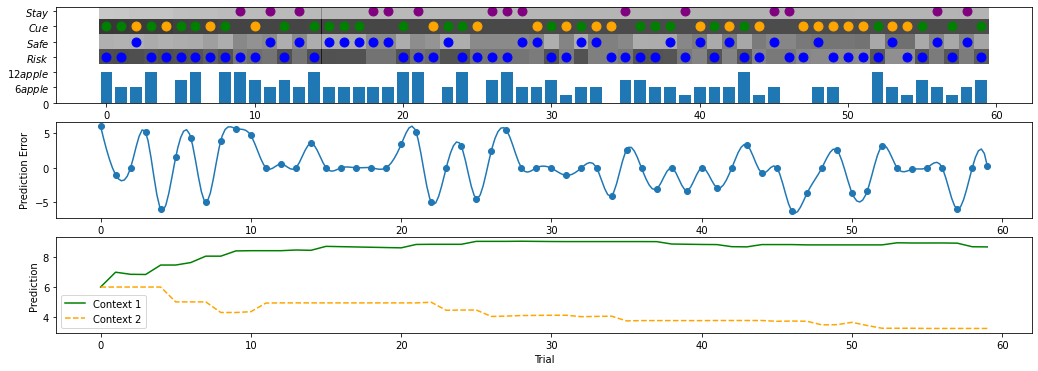

In [44]:
plt.figure(figsize=(17.48,6))
plt.subplot(3,1,1)
plt.scatter(choice_1_P_cue_x,choice_1_P_cue_y,c='black',marker='s',alpha=trial_P_cue,s=220,edgecolors='None')
plt.scatter(choice_1_P_stay_x,choice_1_P_stay_y,c='black',marker='s',alpha=trial_P_stay,s=220,edgecolors='None')
plt.scatter(choice_2_P_risk_x,choice_2_P_risk_y,c='black',marker='s',alpha=trial_P_risk,s=220,edgecolors='None')
plt.scatter(choice_2_P_safe_x,choice_2_P_safe_y,c='black',marker='s',alpha=trial_P_safe,s=220,edgecolors='None')
plt.scatter(choice_1_high_x,choice_1_high_y,c='green',s=80)
plt.scatter(choice_1_low_x,choice_1_low_y,c='orange',s=80)
plt.scatter(choice_1_no_x,choice_1_no_y,c='purple',s=80)
plt.scatter(choice_1_cant_x,choice_1_cant_y,c='grey',s=80)
plt.scatter(choice_2_risk_x,choice_2_risk_y,c='blue',s=80)
plt.scatter(choice_2_safe_x,choice_2_safe_y,c='blue',s=80)
plt.bar(np.arange(0,60),trial_result)

plt.yticks([0,1,2,3,4,5,6],[r'$0$', r'$6 apple$',r'$12 apple$',r'$Risk$',r'$Safe$',r'$Cue$',r'$Stay$'])
# plt.yticks(['0','6 apple','12 apple','Risk','Safe','Cue','Stay'])


plt.subplot(3,1,2)
# plt.plot(np.arange(0,60),trial_prediction_error)
plt.plot(smooth_perdiction_error[0],smooth_perdiction_error[1])
plt.scatter(np.arange(0,60), trial_prediction_error)
plt.ylabel('Prediction Error')
plt.subplot(3,1,3)
plt.plot(np.arange(0,60),trial_pridicted_result_con1,c='green')
plt.plot(np.arange(0,60),trial_pridicted_result_con2,c='orange',ls='dashed')
plt.ylabel('Prediction')
plt.legend(['Context 1','Context 2'])
plt.xlabel('Trial')

c:\ProgramData\Anaconda3\envs\MNE\lib\site-packages\numpy\ma\core.py:2829: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  _data = np.array(data, dtype=dtype, copy=copy,


Text(0.5, 0, 'Trial')

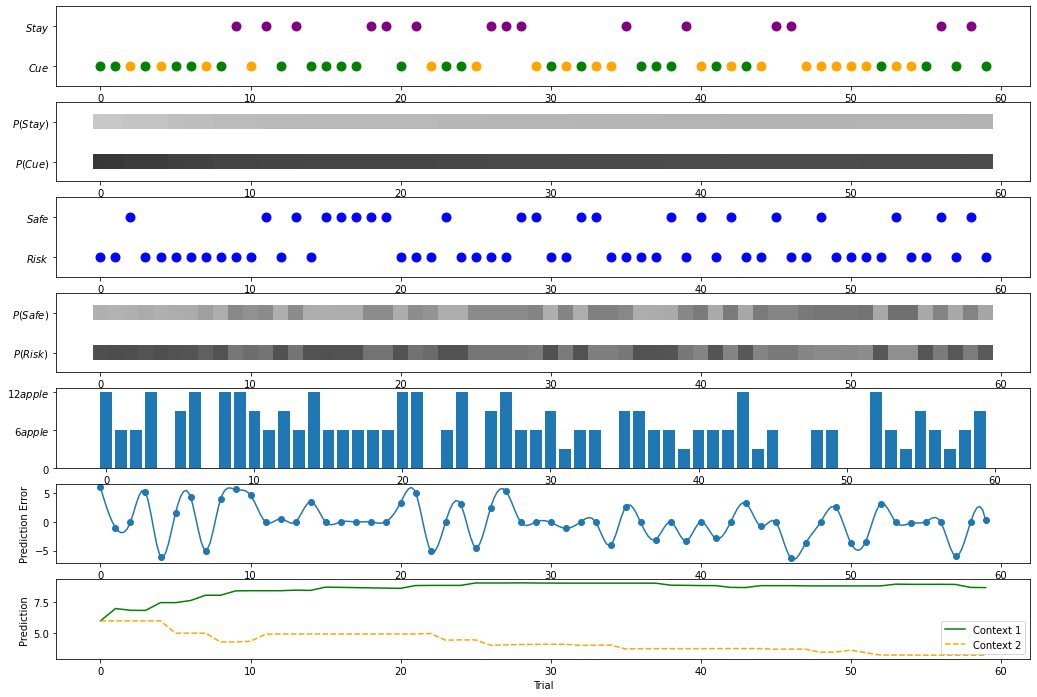

In [56]:
plt.figure(figsize=(17.45,12))
plt.subplot(7,1,1)
choice_1_high_y = np.ones(np.size(choice_1_high_x))
choice_1_low_y = np.ones(np.size(choice_1_low_x))
choice_1_no_y = np.ones(np.size(choice_1_no_x))*2
plt.scatter(choice_1_high_x,choice_1_high_y,c='green',s=80)
plt.scatter(choice_1_low_x,choice_1_low_y,c='orange',s=80)
plt.scatter(choice_1_no_x,choice_1_no_y,c='purple',s=80)
plt.yticks([1,2],[r'$Cue$',r'$Stay$'])
plt.ylim(0.5,2.5)
# plt.yticks(['0','6 apple','12 apple','Risk','Safe','Cue','Stay'])

plt.subplot(7,1,2)
choice_1_P_cue_y = np.ones(np.size(choice_1_P_cue_x))
choice_1_P_stay_y = np.ones(np.size(choice_1_P_stay_x))*2
plt.scatter(choice_1_P_cue_x,choice_1_P_cue_y,c='black',marker='s',alpha=trial_P_cue,s=220,edgecolors='None')
plt.scatter(choice_1_P_stay_x,choice_1_P_stay_y,c='black',marker='s',alpha=trial_P_stay,s=220,edgecolors='None')
plt.yticks([1,2],[r'$P(Cue)$',r'$P(Stay)$'])
plt.ylim(0.5,2.5)

plt.subplot(7,1,3)
choice_2_risk_y = np.ones(np.size(choice_2_risk_x))
choice_2_safe_y = np.ones(np.size(choice_2_safe_x))*2
plt.scatter(choice_2_risk_x,choice_2_risk_y,c='blue',s=80)
plt.scatter(choice_2_safe_x,choice_2_safe_y,c='blue',s=80)
plt.yticks([1,2],[r'$Risk$',r'$Safe$'])
plt.ylim(0.5,2.5)

plt.subplot(7,1,4)
choice_2_P_risk_y = np.ones(np.size(choice_2_P_risk_x))
choice_2_P_safe_y = np.ones(np.size(choice_2_P_safe_x))*2
plt.scatter(choice_2_P_risk_x,choice_2_P_risk_y,c='black',marker='s',alpha=trial_P_risk,s=220,edgecolors='None')
plt.scatter(choice_2_P_safe_x,choice_2_P_safe_y,c='black',marker='s',alpha=trial_P_safe,s=220,edgecolors='None')
plt.yticks([1,2],[r'$P(Risk)$',r'$P(Safe)$'])
plt.ylim(0.5,2.5)

plt.subplot(7,1,5)
plt.bar(np.arange(0,60),trial_result)
plt.yticks([0,1,2],[r'$0$', r'$6 apple$',r'$12 apple$'])

plt.subplot(7,1,6)
# plt.plot(np.arange(0,60),trial_prediction_error)
plt.plot(smooth_perdiction_error[0],smooth_perdiction_error[1])
plt.scatter(np.arange(0,60), trial_prediction_error)
plt.ylabel('Prediction Error')

plt.subplot(7,1,7)
plt.plot(np.arange(0,60),trial_pridicted_result_con1,c='green')
plt.plot(np.arange(0,60),trial_pridicted_result_con2,c='orange',ls='dashed')
plt.ylabel('Prediction')
plt.legend(['Context 1','Context 2'])
plt.xlabel('Trial')

c:\ProgramData\Anaconda3\envs\MNE\lib\site-packages\numpy\ma\core.py:2829: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  _data = np.array(data, dtype=dtype, copy=copy,


Text(0.5, 0, 'Trial')

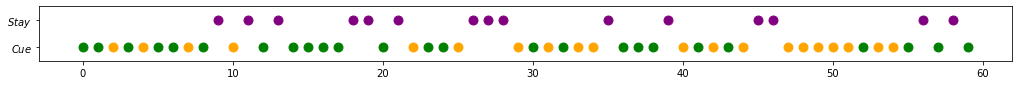

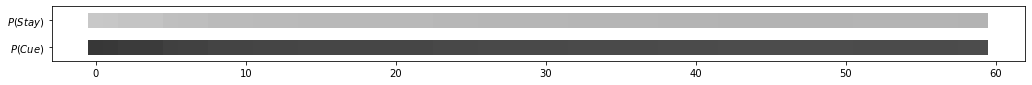

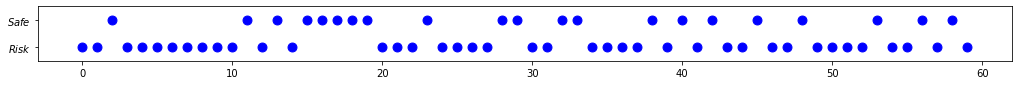

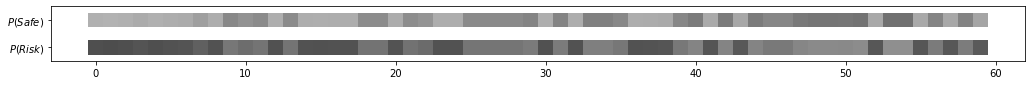

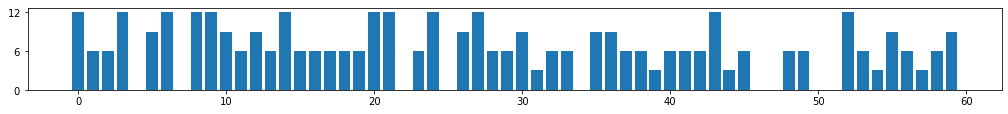

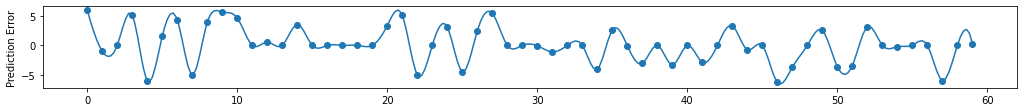

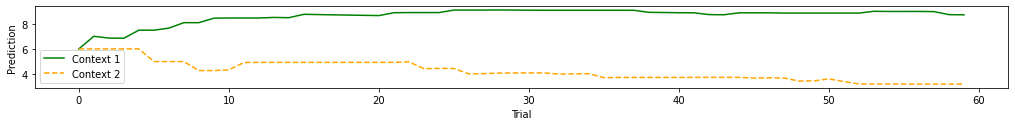

In [72]:
plt.figure(figsize=(17.45,1))
choice_1_high_y = np.ones(np.size(choice_1_high_x))
choice_1_low_y = np.ones(np.size(choice_1_low_x))
choice_1_no_y = np.ones(np.size(choice_1_no_x))*2
plt.scatter(choice_1_high_x,choice_1_high_y,c='green',s=80)
plt.scatter(choice_1_low_x,choice_1_low_y,c='orange',s=80)
plt.scatter(choice_1_no_x,choice_1_no_y,c='purple',s=80)
plt.yticks([1,2],[r'$Cue$',r'$Stay$'])
plt.ylim(0.5,2.5)
# plt.yticks(['0','6 apple','12 apple','Risk','Safe','Cue','Stay'])

plt.figure(figsize=(17.45,1))
choice_1_P_cue_y = np.ones(np.size(choice_1_P_cue_x))
choice_1_P_stay_y = np.ones(np.size(choice_1_P_stay_x))*2
plt.scatter(choice_1_P_cue_x,choice_1_P_cue_y,c='black',marker='s',alpha=trial_P_cue,s=225,edgecolors='None')
plt.scatter(choice_1_P_stay_x,choice_1_P_stay_y,c='black',marker='s',alpha=trial_P_stay,s=225,edgecolors='None')
plt.yticks([1,2],[r'$P(Cue)$',r'$P(Stay)$'])
plt.ylim(0.5,2.5)

plt.figure(figsize=(17.45,1))
choice_2_risk_y = np.ones(np.size(choice_2_risk_x))
choice_2_safe_y = np.ones(np.size(choice_2_safe_x))*2
plt.scatter(choice_2_risk_x,choice_2_risk_y,c='blue',s=80)
plt.scatter(choice_2_safe_x,choice_2_safe_y,c='blue',s=80)
plt.yticks([1,2],[r'$Risk$',r'$Safe$'])
plt.ylim(0.5,2.5)

plt.figure(figsize=(17.45,1))
choice_2_P_risk_y = np.ones(np.size(choice_2_P_risk_x))
choice_2_P_safe_y = np.ones(np.size(choice_2_P_safe_x))*2
plt.scatter(choice_2_P_risk_x,choice_2_P_risk_y,c='black',marker='s',alpha=trial_P_risk,s=220,edgecolors='None')
plt.scatter(choice_2_P_safe_x,choice_2_P_safe_y,c='black',marker='s',alpha=trial_P_safe,s=220,edgecolors='None')
plt.yticks([1,2],[r'$P(Risk)$',r'$P(Safe)$'])
plt.ylim(0.5,2.5)

plt.figure(figsize=(17.45,1.5))
plt.bar(np.arange(0,60),trial_result)
plt.yticks([0,1,2],[r'$0$', r'$6$',r'$12$'])

plt.figure(figsize=(17.45,1.5))
# plt.plot(np.arange(0,60),trial_prediction_error)
plt.plot(smooth_perdiction_error[0],smooth_perdiction_error[1])
plt.scatter(np.arange(0,60), trial_prediction_error)
plt.ylabel('Prediction Error')

plt.figure(figsize=(17.45,1.5))
plt.plot(np.arange(0,60),trial_pridicted_result_con1,c='green')
plt.plot(np.arange(0,60),trial_pridicted_result_con2,c='orange',ls='dashed')
plt.ylabel('Prediction')
plt.legend(['Context 1','Context 2'])
plt.xlabel('Trial')

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or R

(-1.0, 60.0)

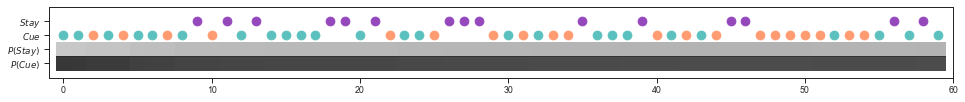

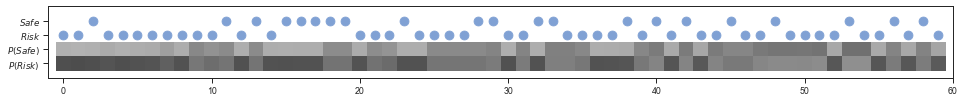

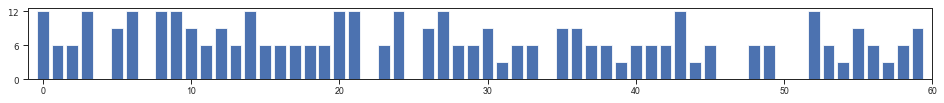

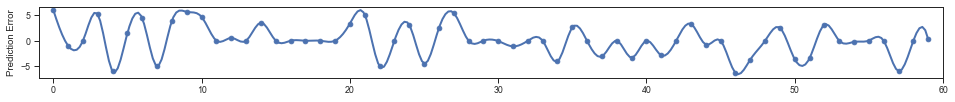

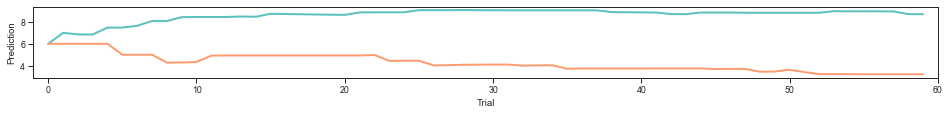

In [109]:
sns.set_context('paper')
x_length = 16.21
plt.figure(figsize=(x_length,1.3))
choice_1_high_y = np.ones(np.size(choice_1_high_x))*3
choice_1_low_y = np.ones(np.size(choice_1_low_x))*3
choice_1_no_y = np.ones(np.size(choice_1_no_x))*4
plt.scatter(choice_1_high_x,choice_1_high_y,c=(91/255, 192/255, 190/255),s=80) #green
plt.scatter(choice_1_low_x,choice_1_low_y,c=(255/255, 155/255, 113/255),s=80) #orange
plt.scatter(choice_1_no_x,choice_1_no_y,c=((148/255, 72/255, 188/255)),s=80) #purple
# plt.yticks(['0','6 apple','12 apple','Risk','Safe','Cue','Stay'])
choice_1_P_cue_y = np.ones(np.size(choice_1_P_cue_x))
choice_1_P_stay_y = np.ones(np.size(choice_1_P_stay_x))*2
plt.scatter(choice_1_P_cue_x,choice_1_P_cue_y,c='black',marker='s',alpha=trial_P_cue,s=220,edgecolors='None')
plt.scatter(choice_1_P_stay_x,choice_1_P_stay_y,c='black',marker='s',alpha=trial_P_stay,s=220,edgecolors='None')
plt.yticks([1,2,3,4],[r'$P(Cue)$',r'$P(Stay)$',r'$Cue$',r'$Stay$'])
plt.ylim(0,5)
plt.xlim(-1,60)

# sns.set(style='ticks')
# sns.despine()

plt.figure(figsize=(x_length,1.31))
choice_2_risk_y = np.ones(np.size(choice_2_risk_x))*3
choice_2_safe_y = np.ones(np.size(choice_2_safe_x))*4
plt.scatter(choice_2_risk_x,choice_2_risk_y,c=(128/255, 161/255, 212/255),s=80) #blue
plt.scatter(choice_2_safe_x,choice_2_safe_y,c=(128/255, 161/255, 212/255),s=80)
choice_2_P_risk_y = np.ones(np.size(choice_2_P_risk_x))
choice_2_P_safe_y = np.ones(np.size(choice_2_P_safe_x))*2
plt.scatter(choice_2_P_risk_x,choice_2_P_risk_y,c='black',marker='s',alpha=trial_P_risk,s=220,edgecolors='None')
plt.scatter(choice_2_P_safe_x,choice_2_P_safe_y,c='black',marker='s',alpha=trial_P_safe,s=220,edgecolors='None')
plt.yticks([1,2,3,4],[r'$P(Risk)$',r'$P(Safe)$',r'$Risk$',r'$Safe$'])
plt.ylim(0,5)
plt.xlim(-1,60)
# sns.set(style='ticks')
# sns.despine()

plt.figure(figsize=(x_length,1.3))
plt.bar(np.arange(0,60),trial_result)
plt.yticks([0,1,2],[r'$0$', r'$6$',r'$12$'])
plt.xlim(-1,60)
# sns.set(style='ticks')
# sns.despine()

plt.figure(figsize=(x_length,1.3))
plt.plot(smooth_perdiction_error[0],smooth_perdiction_error[1],linewidth=2)
plt.scatter(np.arange(0,60), trial_prediction_error)
plt.ylabel('Prediction Error')
plt.xlim(-1,60)
# sns.set(style='ticks')
# sns.despine()

plt.figure(figsize=(x_length,1.3))
plt.plot(np.arange(0,60),trial_pridicted_result_con1,c=(91/255, 192/255, 190/255),linewidth=2) #green
plt.plot(np.arange(0,60),trial_pridicted_result_con2,c=(255/255, 155/255, 113/255),linewidth=2) #orange
plt.ylabel('Prediction')
plt.xlabel('Trial')
plt.xlim(-1,60)
# sns.set(style='ticks')
# sns.despine()